#  Comportamiento de Ventas e inventarios alrededor del terremoto del 10 de agosto de 2026



In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# funciones.py y las carpetas data/ y figuras/ están aquí, o un nivel arriba
RAIZ = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))
import funciones as fn

sns.set_theme(style="whitegrid", context="talk")
PALETA = {"Pre": "#4C72B0", "Durante": "#DD8452", "Post": "#55A868"}
DATA = RAIZ / "data"      # carpeta con los 3 CSV (SEMANA_32, 33 y 34)
FIG = RAIZ / "figuras"
print("datos en:", DATA)

## 1. Cargar los datos

Son tres CSV separados por. Cada fila es un producto en un punto de venta
durante una semana, con sus unidades vendidas, sus ventas en pesos y su
inventario. Los dejamos en una sola base

In [ ]:
bases = fn.cargar_datos(DATA)
print("Filas en total:", f"{len(bases):,}")
print(bases.groupby("semana").size())
bases.head(3)

Filas en total: 2,511,527
semana
32    840255
33    837947
34    833325
dtype: int64


,Semana,GLN Cadena,Cadena,GLN Punto de Venta,Tipo_Supermercado,Región,GTIN,Gln_proveedor,Proveedor,Segmento,Clase,SubCategoria,Unidades vendidas,Ventas,Inventario,semana,periodo
0,32,7701023999083,Cadena 3,7700149469203,No identificado,CENTRO,4067700015419,7707269600011,Competidor 1,Alimentos/Bebidas,Licores,Whisky,3,318384,22,32,Pre
1,32,7701023999083,Cadena 3,7700149469203,No identificado,CENTRO,5010314700003,7707269600011,Competidor 1,Alimentos/Bebidas,Licores,Whisky,1,78142,14,32,Pre
2,32,7701023999083,Cadena 3,7700149469203,No identificado,CENTRO,5010327000039,7707269600011,Competidor 1,Alimentos/Bebidas,Licores,Whisky,28,1917203,134,32,Pre


## 2. Limpieza

Aunque las bases con taban con una limpieza previa por parte del equipo de datos, se reviso si debiamos hacer revisiones adicionales, para asegurar que la información sea confiable

In [ ]:
for w in (32, 33, 34):
    print(f"semana {w}:", bases.loc[bases.semana == w, "Ventas"].dropna().head(3).tolist())

print("\nregiones tal como llegan:", sorted(bases["Región"].dropna().unique())[:14])

semana 32: ['318384', '78142', '1917203']
semana 33: ['212256,24', '1079398,08', '849902,83']


semana 34: ['106128,12', '156285,96', '472236,66']



regiones tal como llegan: ['#N/D', 'ANTIOQUIA', 'BOGOTA', 'BOGOTA ', 'CENTRO', 'COSTA', 'EJE CAFETERO', 'META', 'ORIENTE', 'PACIFICO', 'SANTANDERES', 'SUCRE', 'VALLE']


Sobre las ventas y unidades vacías se tomo una decisión importante: un vacío o un
0 significa que ese producto no se vendió esa semana en ese punto de venta, no
que falte el dato. Así que lo dejamos en 0 y se conservo la fila. El inventario vacío
sí lo tratamos como dato faltante.

También se reviso que la clasificación de cada producto (Segmento, Clase,
subcategoría) sea la misma en las tres semanas. Contando los valores distintos
por semana se ve que coinciden:

In [4]:
bases.groupby("semana")[["Segmento", "Clase", "SubCategoria"]].nunique()

,Segmento,Clase,SubCategoria
semana,,,
32,9,57,385
33,9,56,382
34,9,56,382


In [ ]:
df = fn.limpiar(bases)
reporte = fn.reporte_calidad(bases, df)

print("filas después de limpiar:", f"{len(df):,}")
print("duplicados que se quitó:", reporte["duplicados_eliminados"])
print("líneas sin venta (ventas = 0):", f"{reporte['ventas_cero_o_sin_venta']:,}")
print("% de vacíos en las medidas:", reporte["pct_vacios_medida_cruda"])
print("productos con categoría consistente en las 3 semanas:",
      f"{reporte['taxonomia_consistente_gtin_%']}% ({reporte['gtin_consistentes']})")
print("regiones/familias/categorías/subcategorías:",
      reporte["regiones"], reporte["familias"], reporte["categorias"], reporte["subcategorias"])
df.head(3)

filas después de limpiar: 2,511,527
duplicados que quité: 0
líneas sin venta (ventas = 0): 1,160,880
% de vacíos en las medidas: {'ventas': 33.9, 'unidades': 33.9}
productos con categoría consistente en las 3 semanas: 100.0% (2980/2980)
regiones/familias/categorías/subcategorías: 12 9 57 385


,semana,periodo,cadena,tipo_supermercado,region,punto_venta,gtin,proveedor,familia,categoria,subcategoria,unidades,ventas,inventario
0,32,Pre,Cadena 3,No identificado,CENTRO,7700149469203,4067700015419,Competidor 1,Alimentos/Bebidas,Licores,Whisky,3.0,318384.0,22.0
1,32,Pre,Cadena 3,No identificado,CENTRO,7700149469203,5010314700003,Competidor 1,Alimentos/Bebidas,Licores,Whisky,1.0,78142.0,14.0
2,32,Pre,Cadena 3,No identificado,CENTRO,7700149469203,5010327000039,Competidor 1,Alimentos/Bebidas,Licores,Whisky,28.0,1917203.0,134.0


In [ ]:
assert df["ventas"].isna().sum() == 0
assert df["periodo"].cat.categories.tolist() == ["Pre", "Durante", "Post"]
assert reporte["taxonomia_consistente_gtin_%"] == 100.0
print("Sin ventas nulas, periodo ordenado")

## 3. Análisis descriptivo

### 3.1 ¿Cuánto se vendió en cada semana?

In [7]:
resumen = fn.resumen_por_periodo(df)
resumen

,ventas,unidades,inventario_prom
periodo,,,
Pre,37400357350.0,4069838.0,23.7
Durante,38126286793.800003,4125498.7,23.8
Post,34445409489.599998,3715839.6,23.8


In [8]:
var_ventas = fn.variacion_vs_pre(resumen, "ventas")
var_unidades = fn.variacion_vs_pre(resumen, "unidades")
print(var_ventas, "\n")
print(var_unidades)

                     ventas  var_%_vs_Pre
periodo                                  
Pre           37400357350.0           0.0
Durante  38126286793.800003           1.9
Post     34445409489.599998          -7.9 

          unidades  var_%_vs_Pre
periodo                         
Pre      4069838.0           0.0
Durante  4125498.7           1.4
Post     3715839.6          -8.7


El total casi no se mueve: la semana del sismo vendió 1,9% más en pesos (1,4%
en unidades) que la anterior, y la semana siguiente cayó 7,9%. Nada exagerado en
el total.

### 3.2 Ventas por región

In [9]:
reg = fn.ventas_por_dimension(df, "region", "ventas")
reg[["Pre", "Durante", "Post", "var_Durante_%", "var_Post_%"]].round(0)

periodo,Pre,Durante,Post,var_Durante_%,var_Post_%
region,,,,,
CENTRO,9580454823.0,9490225032.0,8453867004.0,-1.0,-12.0
COSTA,8515898488.0,8326785848.0,6884754427.0,-2.0,-19.0
ANTIOQUIA,5509157366.0,5765500727.0,5679262885.0,5.0,3.0
BOGOTA,5304396166.0,5483075887.0,5616453420.0,3.0,6.0
PACIFICO,2535545103.0,2791602799.0,2169632031.0,10.0,-14.0
VALLE,1894652531.0,2075019404.0,1705169519.0,10.0,-10.0
EJE CAFETERO,1892196444.0,2020439160.0,1789747933.0,7.0,-5.0
ORIENTE,1719358495.0,1696486402.0,1761231276.0,-1.0,2.0
SANTANDERES,259685313.0,303784859.0,241958221.0,17.0,-7.0


La semana del sismo suben sobre todo Pacífico (+10%), Valle
(+9,5%), Eje Cafetero (+6,8%) y Antioquia (+4,7%); Centro y Costa quedan planas.
La semana siguiente casi todas caen (Costa −19%, Centro −12%), menos Bogotá y
Antioquia que aguantan.

### 3.3 Las categorías que suben y las que bajan

Miramos qué categorías crecieron y cuáles
cayeron la semana del sismo frente a la anterior. Solo tenemos en cuenta las que
ya tenían ventas de peso, para que el porcentaje nos dijera algo

In [10]:
suben, bajan = fn.top_movimientos(df, "categoria", n=8)
print("las que más subieron:")
print(suben[["Pre", "Durante", "var_Durante_%"]].round(0))
print("\nlas que más bajaron:")
print(bajan[["Pre", "Durante", "var_Durante_%"]].round(0))

las que más subieron:
periodo                            Pre       Durante  var_Durante_%
categoria                                                          
Cereales                  1610542675.0  2155106464.0           34.0
Bebidas                   7605853570.0  9551410425.0           26.0
Vegetales / Verduras       191835496.0   240605762.0           25.0
Conservas / Encurtidos     449360576.0   528110196.0           18.0
Harinas                    266567773.0   301796534.0           13.0
Licores                   3603400358.0  4004915625.0           11.0
Pastas                     656454264.0   721516620.0           10.0
Peces / Mariscos del mar   345842530.0   352037997.0            2.0

las que más bajaron:
periodo                                Pre       Durante  var_Durante_%
categoria                                                              
Café                          1533357840.0  1062965568.0          -31.0
Sustitutos de origen animal    103894982.0    74603211.0    

In [ ]:
suben_sub, _ = fn.top_movimientos(df, "subcategoria", n=10)
suben_sub[["Pre", "Durante", "var_Durante_%"]].round(0)

periodo,Pre,Durante,var_Durante_%
subcategoria,,,
Cerveza rojas,73526617.0,202672270.0,176.0
Paquete surtido de pasabocas (papas + platanitos + palomitas),24113450.0,50351288.0,109.0
Pack mixto de bebidas alcohólicas,545542461.0,1084342285.0,99.0
Paquetes surtidos de legumbres,42244202.0,80779024.0,91.0
Agua pura/ Manantial,1140018768.0,1848479070.0,62.0
Chocolates líquidos / maltas líquidas,192135752.0,273853824.0,42.0
Lenteja,39416007.0,55711421.0,41.0
Arroz,1492184455.0,2046923581.0,37.0
Cerveza sin alcohol,21629521.0,29292561.0,35.0


### 3.4 Inventario y quiebres

Miramos el inventario total y el porcentaje de líneas
producto–punto de venta que quedaron en cero.

In [12]:
fn.analisis_inventario(df)

,inventario_total,tasa_quiebre_pct
periodo,,
Pre,19890286.0,9.0
Durante,19977645.036,9.1
Post,19854915.796,9.1


El inventario total y la tasa de quiebre se quedan quietos, alrededor del 9%
en las tres semanas. O sea, a nivel general no hubo desabastecimiento: la oferta
aguantó aunque la demanda se reacomodara.

## 4. Gráficos


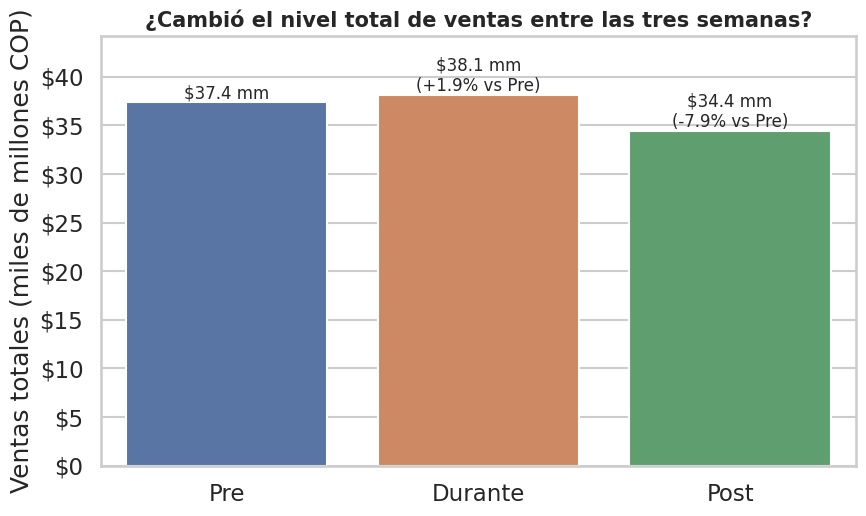

In [ ]:
def a_mmm(x, pos=None):
    return f"${x/1e9:.0f}"

serie = resumen["ventas"].reindex(fn.ORDEN_PERIODO)
varp = var_ventas["var_%_vs_Pre"].reindex(fn.ORDEN_PERIODO)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=serie.index, y=serie.values, hue=serie.index, palette=PALETA, legend=False, ax=ax)
ax.set_title("¿Cambió el nivel total de ventas entre las tres semanas?", fontsize=15, weight="bold")
ax.set_xlabel(""); ax.set_ylabel("Ventas totales (miles de millones COP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(a_mmm))
for i, v in enumerate(serie.values):
    txt = f"${v/1e9:.1f} mm" + ("" if i == 0 else f"\n({varp.iloc[i]:+.1f}% vs Pre)")
    ax.text(i, v, txt, ha="center", va="bottom", fontsize=12)
ax.margins(y=0.16)
plt.tight_layout()
plt.savefig(FIG / "fig1_ventas_por_periodo.png", dpi=150, bbox_inches="tight")
plt.show()

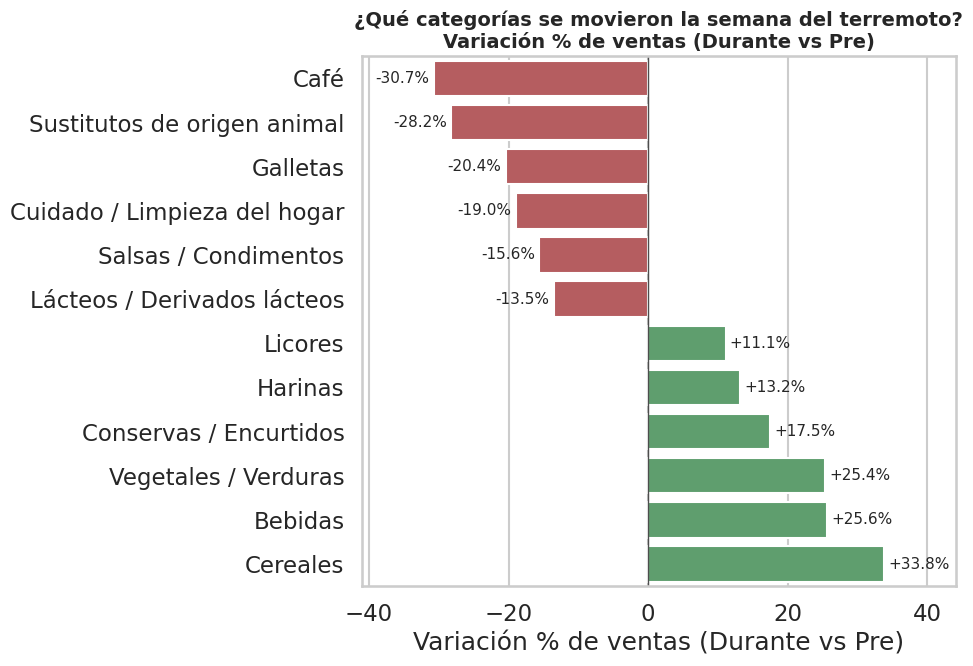

In [ ]:
mov = pd.concat([suben.head(6), bajan.head(6)]).sort_values("var_Durante_%")
colores = ["#C44E52" if v < 0 else "#55A868" for v in mov["var_Durante_%"]]

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=mov["var_Durante_%"], y=mov.index, hue=mov.index, palette=colores, legend=False, ax=ax)
ax.axvline(0, color="0.3", lw=1)
ax.set_title("¿Qué categorías se movieron la semana del terremoto?\n"
             "Variación % de ventas (Durante vs Pre)", fontsize=14, weight="bold")
ax.set_xlabel("Variación % de ventas (Durante vs Pre)"); ax.set_ylabel("")
for i, v in enumerate(mov["var_Durante_%"]):
    ax.text(v + (0.6 if v >= 0 else -0.6), i, f"{v:+.1f}%",
            va="center", ha="left" if v >= 0 else "right", fontsize=11)
ax.margins(x=0.16)
plt.tight_layout()
plt.savefig(FIG / "fig2_recomposicion_canasta.png", dpi=150, bbox_inches="tight")
plt.show()

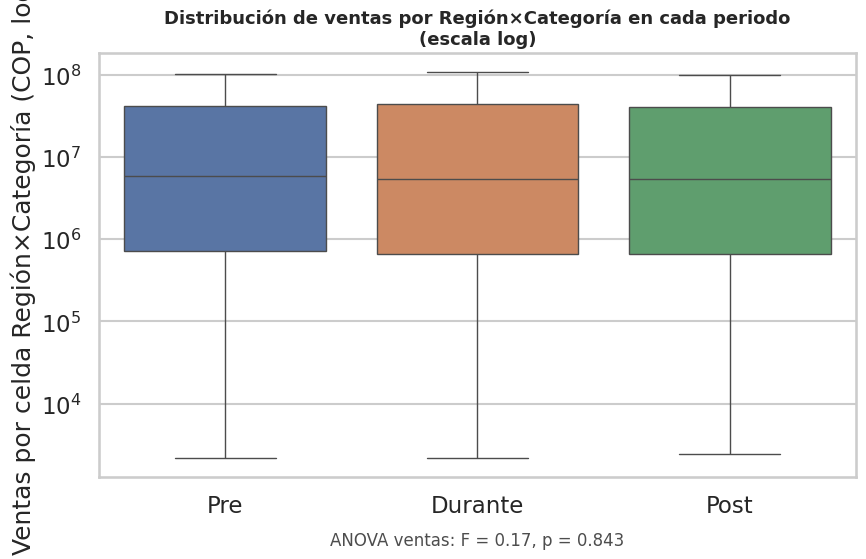

In [ ]:
muestras = fn.muestras_por_periodo(df, "ventas")
largo = (pd.DataFrame({p: pd.Series(m) for p, m in zip(fn.ORDEN, muestras)})
           .melt(var_name="periodo", value_name="ventas"))
largo = largo[largo["ventas"] > 0]
res_v = fn.anova(df, "ventas")

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=largo, x="periodo", y="ventas", hue="periodo", order=fn.ORDEN_PERIODO,
            palette=PALETA, legend=False, showfliers=False, ax=ax)
ax.set_yscale("log")
ax.set_title("Distribución de ventas por Región×Categoría en cada periodo\n(escala log)",
             fontsize=13, weight="bold")
ax.set_xlabel(""); ax.set_ylabel("Ventas por celda Región×Categoría (COP, log)")
ax.text(0.5, -0.16, f"ANOVA ventas: F = {res_v['F']:.2f}, p = {res_v['p_value']:.3g}",
        transform=ax.transAxes, ha="center", fontsize=12, color="0.3")
plt.tight_layout()
plt.savefig(FIG / "fig3_anova_ventas_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Prueba de hipótesis (ANOVA)

Se Planteo la prueba con los tres periodos como grupos:

- **H0:** las ventas promedio son iguales en Pre, Durante y Post.
- **H1:** al menos un periodo es distinto.

Se comparo sobre las ventas por Región×Categoría (una celda por combinación y
periodo), con α = 0,05. 

In [16]:
res_ventas = fn.anova(df, "ventas")
res_unidades = fn.anova(df, "unidades")
for r in (res_ventas, res_unidades):
    print(f"ANOVA {r['valor']}: F = {r['F']}, p = {r['p_value']:.4f}, "
          f"{'se rechaza' if r['rechaza_H0'] else 'no se rechaza'} H0")

pd.DataFrame({"Ventas": res_ventas, "Unidades": res_unidades}).loc[
    ["n_por_grupo", "F", "p_value", "eta2", "levene_p", "kruskal_p", "friedman_p", "rechaza_H0"]]

ANOVA ventas: F = 0.171, p = 0.8429, no se rechaza H0
ANOVA unidades: F = 0.111, p = 0.8952, no se rechaza H0


,Ventas,Unidades
n_por_grupo,583,583
F,0.171,0.111
p_value,0.842936,0.895151
eta2,0.0002,0.0001
levene_p,0.848356,0.898886
kruskal_p,0.583487,0.612996
friedman_p,0.0,0.0
rechaza_H0,False,False


El ANOVA **no rechaza H0**: para ventas F(2, 1746) = 0,17 (p = 0,84) y para
unidades p = 0,90. Las varianzas son homogéneas (Levene p > 0,8), Kruskal-Wallis
dice lo mismo (p > 0,5) y el tamaño del efecto es casi cero. En promedio, las
ventas por Región×Categoría no cambian entre periodos, que es coherente con el
gráfico 1: los aumentos de unas categorías se compensan con las caídas de otras.


### 5.1 El mismo ANOVA, pero solo en las regiones que más subieron

Como el descriptivo mostró que el alza se concentró en unas regiones, se planteo nuevamente la
prueba solo con Pacífico, Valle, Eje Cafetero y Antioquia, a ver si ahí sí sale
un cambio significativo.

In [17]:
foco_ventas = fn.anova_regiones(df, "ventas")
foco_unidades = fn.anova_regiones(df, "unidades")
print("regiones:", ", ".join(fn.REGIONES_FOCO))
for r in (foco_ventas, foco_unidades):
    print(f"ANOVA {r['valor']} (foco): F = {r['F']}, p = {r['p_value']:.4f}, "
          f"{'se rechaza' if r['rechaza_H0'] else 'no se rechaza'} H0")

regiones: PACIFICO, VALLE, EJE CAFETERO, ANTIOQUIA
ANOVA ventas (foco): F = 0.09, p = 0.9139, no se rechaza H0
ANOVA unidades (foco): F = 0.082, p = 0.9212, no se rechaza H0


Tampoco. Incluso en esas cuatro regiones el ANOVA sigue sin rechazar H0
(ventas p = 0,91; unidades p = 0,92): el nivel promedio no cambia porque dentro
de cada región también conviven categorías que suben con otras que bajan.
Friedman vuelve a marcar el cambio sistemático (p < 0,001). La conclusión es que
el terremoto no se ve como un salto en el promedio de ventas, sino como una
recomposición de la canasta.

## 6. Verificación


In [18]:
# totales de control: bases vs pipeline
control = (fn.a_numero(bases["Ventas"]).fillna(0)
           .groupby(bases["periodo"]).sum().reindex(fn.ORDEN_PERIODO))
obtenido = df.groupby("periodo", observed=True)["ventas"].sum().reindex(fn.ORDEN_PERIODO)
chequeo = pd.DataFrame({"control": control, "pipeline": obtenido})
chequeo["ok"] = np.isclose(chequeo["control"], chequeo["pipeline"])
print(chequeo)
assert chequeo["ok"].all()
print("los totales coinciden")

                    control            pipeline    ok
periodo                                              
Pre           37400357350.0       37400357350.0  True
Durante    38126286793.7789    38126286793.7789  True
Post     34445409489.582802  34445409489.582802  True
los totales coinciden


In [19]:
alfa = 0.05
print(f"rechazo H0 si p < {alfa}")
print(f"  ANOVA ventas          p = {res_ventas['p_value']:.4f} -> {'rechazo' if res_ventas['p_value']<alfa else 'no rechazo'}")
print(f"  ANOVA unidades        p = {res_unidades['p_value']:.4f} -> {'rechazo' if res_unidades['p_value']<alfa else 'no rechazo'}")
print(f"  ANOVA ventas (foco)   p = {foco_ventas['p_value']:.4f} -> {'rechazo' if foco_ventas['p_value']<alfa else 'no rechazo'}")
print(f"  Friedman ventas       p = {res_ventas['friedman_p']:.2e} -> {'rechazo' if res_ventas['friedman_p']<alfa else 'no rechazo'}")

rechazo H0 si p < 0.05
  ANOVA ventas          p = 0.8429 -> no rechazo
  ANOVA unidades        p = 0.8952 -> no rechazo
  ANOVA ventas (foco)   p = 0.9139 -> no rechazo
  Friedman ventas       p = 1.36e-28 -> rechazo
